# 🎬 Movie Recommendation System (Collaborative Filtering)

This project builds a movie recommendation system using user rating data.  
We apply **collaborative filtering** to recommend similar movies based on user preferences.

---

## 📌 Objectives
- Explore and clean movie & rating datasets
- Analyze rating distribution and popular movies
- Build a user-movie matrix
- Compute movie similarity using cosine similarity
- Generate movie recommendations

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/credits.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/keywords.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

## 📂 Load Dataset

We use the MovieLens dataset, including:
- `ratings_small.csv`: user ratings
- `movies_metadata.csv`: movie information

We load the data using pandas and inspect its structure.

In [3]:
ratings = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv')
movies = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv')

## 🔍 Data Overview

We check:
- Dataset size
- Column types
- Missing values

This helps us understand data quality before cleaning.

In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [5]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [6]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

print("\nRatings info:")
print(ratings.info())

print("\nMovies info:")
print(movies.info())

Ratings shape: (100004, 4)
Movies shape: (45466, 24)

Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 

In [7]:
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64


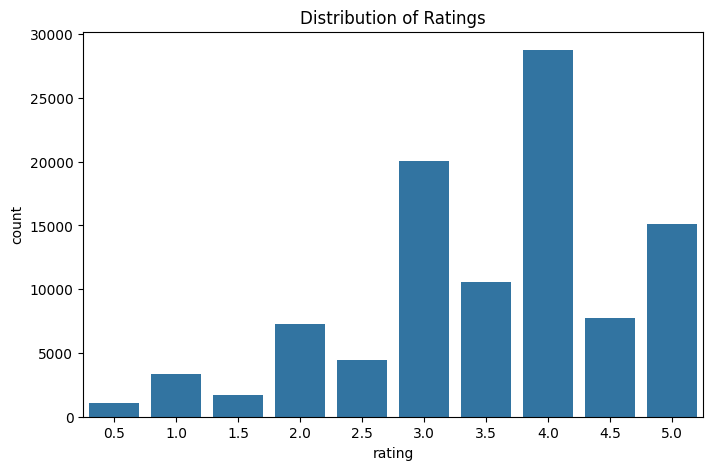

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=ratings)
plt.title('Distribution of Ratings')
plt.show()

## 🧹 Data Cleaning

The `movies_metadata` dataset contains:
- Non-numeric IDs
- Duplicate entries

We:
- Convert `id` to numeric
- Remove invalid values
- Drop duplicates

This ensures consistency for merging.

In [9]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

print(ratings.head())
print(movies[['id', 'title']].head())

Ratings shape: (100004, 4)
Movies shape: (45466, 24)
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
      id                        title
0    862                    Toy Story
1   8844                      Jumanji
2  15602             Grumpier Old Men
3  31357            Waiting to Exhale
4  11862  Father of the Bride Part II


In [10]:
movies = movies[['id', 'title']].copy()

movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)

movies = movies.drop_duplicates(subset='id')

movies.head()

,id,title
0,862,Toy Story
1,8844,Jumanji
2,15602,Grumpier Old Men
3,31357,Waiting to Exhale
4,11862,Father of the Bride Part II


In [11]:
df = ratings.merge(movies, left_on='movieId', right_on='id', how='inner')
df.head()

,userId,movieId,rating,timestamp,id,title
0,1,1371,2.5,1260759135,1371,Rocky III
1,1,1405,1.0,1260759203,1405,Greed
2,1,2105,4.0,1260759139,2105,American Pie
3,1,2193,2.0,1260759198,2193,My Tutor
4,1,2294,2.0,1260759108,2294,Jay and Silent Bob Strike Back


## 🔗 Merge Datasets

We merge:
- `ratings.movieId`
- `movies.id`

This creates a unified dataset linking:
- users
- ratings
- movie titles

In [12]:
print(df.shape)
print(df[['userId', 'movieId', 'rating', 'title']].head())

(44989, 6)
   userId  movieId  rating                           title
0       1     1371     2.5                       Rocky III
1       1     1405     1.0                           Greed
2       1     2105     4.0                    American Pie
3       1     2193     2.0                        My Tutor
4       1     2294     2.0  Jay and Silent Bob Strike Back


## 📈 Rating Distribution

We visualize how ratings are distributed.

Insight:
- Most ratings are between **3 and 4**
- Users tend to give relatively high ratings

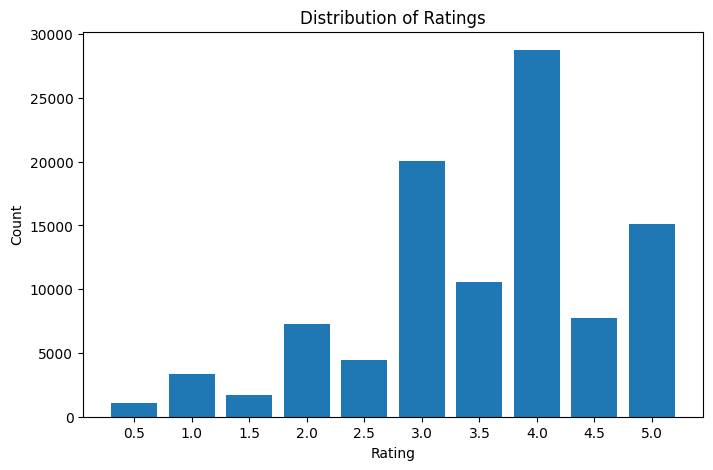

In [13]:
rating_counts = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [14]:
movie_stats = df.groupby('title').agg({
    'rating': ['mean', 'count']
}).reset_index()

movie_stats.columns = ['title', 'avg_rating', 'rating_count']

movie_stats = movie_stats.sort_values(by='rating_count', ascending=False)
movie_stats.head(10)

,title,avg_rating,rating_count
1959,Terminator 3: Rise of the Machines,4.256173,324
2306,The Million Dollar Hotel,4.487138,311
1837,Solaris,4.134426,305
1967,The 39 Steps,4.221649,291
1374,Monsoon Wedding,3.706204,274
1506,Once Were Warriors,4.303279,244
2549,Three Colors: Red,3.945175,228
1331,Men in Black II,4.256696,224
2354,The Passion of Joan of Arc,3.483945,218
1807,Silent Hill,3.674419,215


## 🎬 Most Popular Movies

We calculate:
- Average rating
- Number of ratings per movie

Then identify the most frequently rated movies.

Insight:
- Popular movies dominate user interactions
- These are good candidates for recommendations

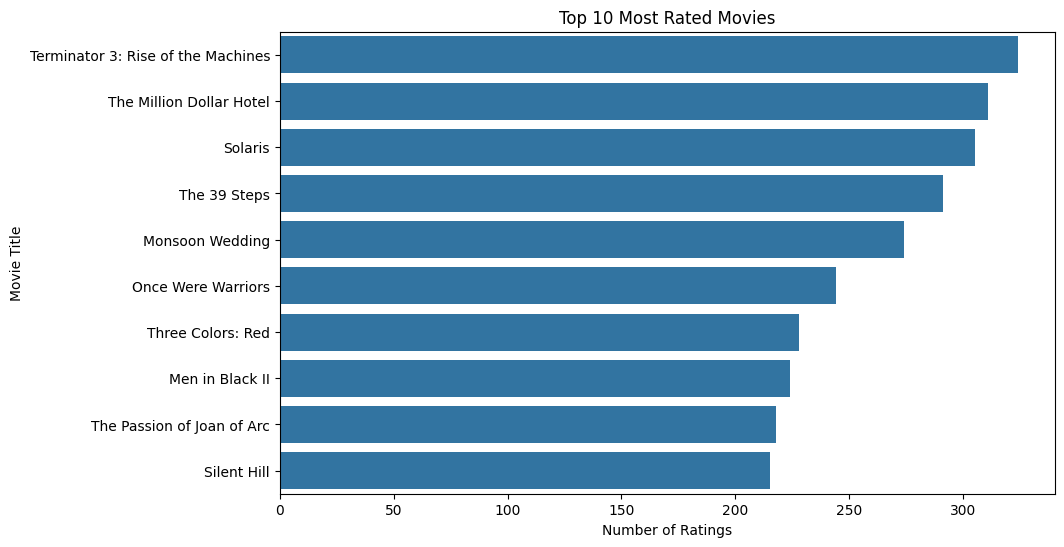

In [15]:
top10 = movie_stats.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='rating_count', y='title')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

## Error

In [16]:
user_movie_matrix = df.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

user_movie_matrix.head()

title,!Women Art Revolution,'Gator Bait,'Twas the Night Before Christmas,...And God Created Woman,00 Schneider - Jagd auf Nihil Baxter,10 Items or Less,10 Things I Hate About You,"10,000 BC",11'09''01 - September 11,12 Angry Men,...,Zodiac,Zombie Flesh Eaters,Zombie Holocaust,Zozo,eXistenZ,xXx,¡Three Amigos!,À nos amours,Ödipussi,Şaban Oğlu Şaban
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
movie_rating_counts = df['title'].value_counts()
popular_movies = movie_rating_counts[movie_rating_counts >= 20].index

filtered_matrix = user_movie_matrix[popular_movies]
filtered_matrix.head()

title,Terminator 3: Rise of the Machines,The Million Dollar Hotel,Solaris,The 39 Steps,Monsoon Wedding,Once Were Warriors,Three Colors: Red,Men in Black II,The Passion of Joan of Arc,Silent Hill,...,Bandido!,Guter Junge,The Door in the Floor,Irma la Douce,Breaking and Entering,Mr. Smith Goes to Washington,The Mikado,L.A. Confidential,Valkyrie,Running Out of Time
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,3.0,NaN,4.0,4.0,4.0,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.5,5.0,3.0,NaN,NaN,3.0,4.0,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,5.0,5.0,NaN,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
movie_user_matrix = filtered_matrix.T.fillna(0)

movie_similarity = cosine_similarity(movie_user_matrix)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

movie_similarity_df.iloc[:5, :5]

title,Terminator 3: Rise of the Machines,The Million Dollar Hotel,Solaris,The 39 Steps,Monsoon Wedding
title,,,,,
Terminator 3: Rise of the Machines,1.000000,0.673955,0.701774,0.551170,0.599708
The Million Dollar Hotel,0.673955,1.000000,0.658833,0.534023,0.528334
Solaris,0.701774,0.658833,1.000000,0.524042,0.634380
The 39 Steps,0.551170,0.534023,0.524042,1.000000,0.524038
Monsoon Wedding,0.599708,0.528334,0.634380,0.524038,1.000000


In [19]:
def recommend_movies(movie_title, top_n=10):
    if movie_title not in movie_similarity_df.columns:
        return f"Movie '{movie_title}' not found in filtered dataset."
    
    sim_scores = movie_similarity_df[movie_title].sort_values(ascending=False)[1:top_n+1]
    return sim_scores

In [20]:
recommend_movies('Toy Story', top_n=10)

"Movie 'Toy Story' not found in filtered dataset."

In [21]:
[col for col in movie_similarity_df.columns if 'Toy Story' in col][:10]

[]

## end
## 🔗 Correct ID Mapping Between Datasets

The `ratings_small.csv` dataset uses **MovieLens movieId**, while `movies_metadata.csv` uses **TMDB id**.  
Therefore, we cannot merge them directly.

To correctly link ratings with movie titles, we use `links_small.csv` as a bridge:
- `ratings_small.movieId` → `links_small.movieId`
- `links_small.tmdbId` → `movies_metadata.id`

This step ensures the recommendation results are based on the correct movie titles.

In [22]:
links = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/links_small.csv')
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [23]:
movies = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv')
ratings = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv')

movies = movies[['id', 'title']].copy()
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)
movies = movies.drop_duplicates(subset='id')

links = links[['movieId', 'tmdbId']].copy()
links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce')
links = links.dropna(subset=['tmdbId'])
links['tmdbId'] = links['tmdbId'].astype(int)

print(links.head())
print(movies.head())

   movieId  tmdbId
0        1     862
1        2    8844
2        3   15602
3        4   31357
4        5   11862
      id                        title
0    862                    Toy Story
1   8844                      Jumanji
2  15602             Grumpier Old Men
3  31357            Waiting to Exhale
4  11862  Father of the Bride Part II


In [24]:
ratings_links = ratings.merge(links, on='movieId', how='inner')
ratings_links.head()

,userId,movieId,rating,timestamp,tmdbId
0,1,31,2.5,1260759144,9909
1,1,1029,3.0,1260759179,11360
2,1,1061,3.0,1260759182,819
3,1,1129,2.0,1260759185,1103
4,1,1172,4.0,1260759205,11216


In [25]:
df = ratings_links.merge(movies, left_on='tmdbId', right_on='id', how='inner')
df = df[['userId', 'movieId', 'rating', 'title']]

print(df.shape)
df.head()

(99810, 4)


,userId,movieId,rating,title
0,1,31,2.5,Dangerous Minds
1,1,1029,3.0,Dumbo
2,1,1061,3.0,Sleepers
3,1,1129,2.0,Escape from New York
4,1,1172,4.0,Cinema Paradiso


In [26]:
[df_title for df_title in df['title'].unique() if 'Toy Story' in df_title][:20]

['Toy Story 2', 'Toy Story', 'Toy Story 3', 'Toy Story of Terror!']

## 🧱 User-Movie Matrix

We create a pivot table:
- Rows → users
- Columns → movies
- Values → ratings

This matrix is the foundation of collaborative filtering.

In [27]:
user_movie_matrix = df.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)
user_movie_matrix.head()

title,$9.99,'Neath the Arizona Skies,"'night, Mother",(500) Days of Summer,...And God Created Woman,...And Justice for All,1-900,10,10 Attitudes,10 Cloverfield Lane,...,eXistenZ,loudQUIETloud: A Film About the Pixies,xXx,xXx: State of the Union,¡Three Amigos!,À Nous la Liberté,Æon Flux,İtirazım Var,Želary,’Round Midnight
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔥 Filter Popular Movies

To reduce sparsity and noise, we:
- Keep movies with at least **20 ratings**

This improves recommendation quality and computation efficiency.

In [28]:
movie_rating_counts = df['title'].value_counts()
popular_movies = movie_rating_counts[movie_rating_counts >= 20].index

filtered_matrix = user_movie_matrix[popular_movies]
filtered_matrix.head()

title,Forrest Gump,Pulp Fiction,The Shawshank Redemption,The Silence of the Lambs,Star Wars,Jurassic Park,The Matrix,Toy Story,Schindler's List,Terminator 2: Judgment Day,...,Looper,Flatliners,Bio-Dome,Zodiac,The League of Extraordinary Gentlemen,Steel Magnolias,The 6th Day,Inspector Gadget,My Favorite Year,The Paper
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,4.0,NaN,3.0,NaN,4.0,NaN,NaN,4.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,5.0,4.5,5.0,3.0,NaN,NaN,NaN,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,5.0,NaN,NaN,5.0,5.0,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🤝 Compute Movie Similarity

We compute similarity between movies using:
- Cosine similarity

This measures how similar two movies are based on user ratings.

In [29]:
movie_user_matrix = filtered_matrix.T.fillna(0)

movie_similarity = cosine_similarity(movie_user_matrix)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

movie_similarity_df.iloc[:5, :5]

title,Forrest Gump,Pulp Fiction,The Shawshank Redemption,The Silence of the Lambs,Star Wars
title,,,,,
Forrest Gump,1.000000,0.655243,0.657244,0.667731,0.543636
Pulp Fiction,0.655243,1.000000,0.673955,0.702355,0.551170
The Shawshank Redemption,0.657244,0.673955,1.000000,0.659378,0.534023
The Silence of the Lambs,0.667731,0.702355,0.659378,1.000000,0.524475
Star Wars,0.543636,0.551170,0.534023,0.524475,1.000000


## 🎯 Recommendation Function

We build a function that:
- Takes a movie title as input
- Returns top-N similar movies

This is the core of our recommendation system.

In [30]:
def recommend_movies(movie_title, top_n=10):
    if movie_title not in movie_similarity_df.columns:
        return f"Movie '{movie_title}' not found in filtered dataset."

    sim_scores = movie_similarity_df[movie_title].sort_values(ascending=False)[1:top_n+1]

    recommendations = pd.DataFrame({
        'Movie': sim_scores.index,
        'Similarity Score': sim_scores.values
    })

    return recommendations

In [31]:
recommend_movies('Toy Story', top_n=10)

,Movie,Similarity Score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


In [32]:
[df_title for df_title in movie_similarity_df.columns if 'Toy Story' in df_title][:20]

['Toy Story', 'Toy Story 2', 'Toy Story 3']

In [33]:
recommend_movies('Toy Story', top_n=10)

,Movie,Similarity Score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


## 🎬 Test Recommendation Results

To verify that the recommendation system works properly, we test it on several well-known movies.

This helps us check whether the recommended movies are semantically and behaviorally similar from the users' rating perspective.

In [34]:
recommend_movies('Toy Story', top_n=10)

,Movie,Similarity Score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


In [35]:
recommend_movies('Pulp Fiction', top_n=10)

,Movie,Similarity Score
0,The Silence of the Lambs,0.702355
1,The Shawshank Redemption,0.673955
2,Se7en,0.672905
3,Forrest Gump,0.655243
4,The Usual Suspects,0.644563
5,Jurassic Park,0.599708
6,The Fugitive,0.598858
7,Schindler's List,0.589488
8,Reservoir Dogs,0.584888
9,Braveheart,0.584754


In [36]:
recommend_movies('Star Wars', top_n=10)

,Movie,Similarity Score
0,The Empire Strikes Back,0.799143
1,Return of the Jedi,0.762233
2,Raiders of the Lost Ark,0.709537
3,Back to the Future,0.640117
4,The Matrix,0.634697
5,Indiana Jones and the Last Crusade,0.607532
6,The Lord of the Rings: The Fellowship of the Ring,0.595748
7,Die Hard,0.590403
8,The Terminator,0.583456
9,Toy Story,0.576188


In [37]:
recommend_movies('Forrest Gump', top_n=10)

,Movie,Similarity Score
0,Jurassic Park,0.688040
1,The Silence of the Lambs,0.667731
2,Braveheart,0.658261
3,The Shawshank Redemption,0.657244
4,Pulp Fiction,0.655243
5,Speed,0.627626
6,The Fugitive,0.622488
7,Terminator 2: Judgment Day,0.619415
8,Back to the Future,0.608397
9,The Lion King,0.602429


## 🧾 Recommendation Output Format

To make the output more readable, we create a helper function that displays the recommended movies in a clean ranked format.

In [38]:
def show_recommendations(movie_title, top_n=10):
    recs = recommend_movies(movie_title, top_n)
    
    if isinstance(recs, str):
        print(recs)
    else:
        print(f"Top {top_n} recommendations for '{movie_title}':\n")
        for i, row in enumerate(recs.itertuples(index=False), start=1):
            print(f"{i}. {row[0]}  |  similarity = {row[1]:.4f}")

In [39]:
show_recommendations('Toy Story', top_n=10)

Top 10 recommendations for 'Toy Story':

1. Toy Story 2  |  similarity = 0.5947
2. Star Wars  |  similarity = 0.5762
3. Forrest Gump  |  similarity = 0.5645
4. Independence Day  |  similarity = 0.5629
5. Groundhog Day  |  similarity = 0.5480
6. Back to the Future  |  similarity = 0.5367
7. Jurassic Park  |  similarity = 0.5352
8. Shrek  |  similarity = 0.5327
9. Return of the Jedi  |  similarity = 0.5293
10. Pulp Fiction  |  similarity = 0.5269


## 🔍 Case Study: Why Does the System Recommend These Movies?

For example, after entering **Toy Story**, the system recommends movies such as:

- Toy Story 2
- Star Wars
- Forrest Gump
- Jurassic Park

This suggests that users who liked *Toy Story* also tended to rate these movies highly.  
The recommendation system captures similarity based on shared user rating behavior rather than genre labels alone.

## 📊 Visualizing Recommendation Similarity Scores

We visualize the top recommended movies and their similarity scores for a given input movie.
This makes the recommendation output easier to interpret.

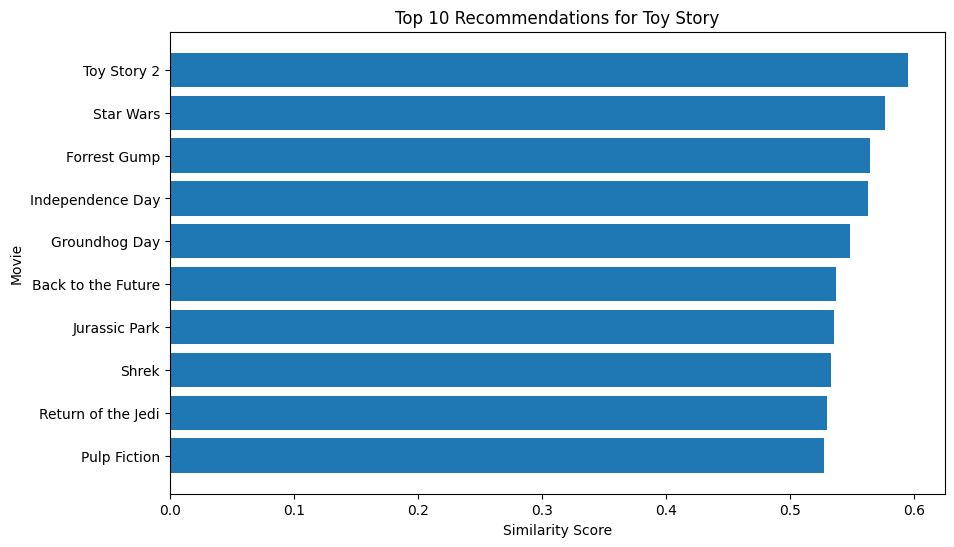

In [40]:
toy_story_recs = recommend_movies('Toy Story', top_n=10)

plt.figure(figsize=(10,6))
plt.barh(toy_story_recs['Movie'][::-1], toy_story_recs['Similarity Score'][::-1])
plt.title("Top 10 Recommendations for Toy Story")
plt.xlabel("Similarity Score")
plt.ylabel("Movie")
plt.show()

## 🧠 Key Findings

- The recommendation system successfully identifies similar movies based on user rating patterns.
- Popular movies such as **Toy Story**, **Star Wars**, and **Pulp Fiction** generate meaningful recommendation results.
- Filtering out low-frequency movies helps reduce sparsity and improves recommendation quality.
- Cosine similarity works well as a simple and interpretable baseline for collaborative filtering.

## ⚠️ Limitations

This project still has several limitations:

- It only uses collaborative filtering based on ratings, without movie content features such as genre, overview, or keywords.
- New movies with few ratings may not appear in the recommendation results.
- New users without rating history cannot receive personalized recommendations (cold start problem).
- Similarity is based on observed ratings only, so the system may miss deeper semantic relationships between films.

## 🚀 Future Improvements

Possible next steps for improving this recommendation system include:

- Adding content-based filtering using genres, keywords, and movie overviews
- Building a hybrid recommendation system
- Using matrix factorization methods such as SVD
- Creating an interactive app with Streamlit for movie search and recommendation display

## 🎬 Prepare Content Features

To build a content-based recommender, we need movie metadata such as:

- title
- genres
- overview

These features help measure similarity based on movie content rather than user behavior.

In [41]:
movies_full = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv')

movies_full = movies_full[['id', 'title', 'genres', 'overview']].copy()

movies_full['id'] = pd.to_numeric(movies_full['id'], errors='coerce')
movies_full = movies_full.dropna(subset=['id'])
movies_full['id'] = movies_full['id'].astype(int)

movies_full['overview'] = movies_full['overview'].fillna('')
movies_full = movies_full.drop_duplicates(subset='id')

movies_full.head()

,id,title,genres,overview
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","Led by Woody, Andy's toys live happily in his ..."
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",When siblings Judy and Peter discover an encha...
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",A family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","Cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",Just when George Banks has recovered from his ...


## 🏷 Parse Genres

The `genres` column is stored as a stringified list of dictionaries.

We convert it into plain text, so it can be used in text vectorization later.

In [42]:
import ast

def parse_genres(x):
    try:
        genres_list = ast.literal_eval(x)
        return ' '.join([i['name'] for i in genres_list])
    except:
        return ''

movies_full['genres_text'] = movies_full['genres'].apply(parse_genres)

movies_full[['title', 'genres', 'genres_text']].head()

,title,genres,genres_text
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",Animation Comedy Family
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Adventure Fantasy Family
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Romance Comedy
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Comedy Drama Romance
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",Comedy


## 🧩 Build Combined Content Feature

We combine:

- genre information
- movie overview

into one text field called `content`.

This will be used to calculate movie-to-movie similarity.

In [43]:
movies_full['content'] = movies_full['genres_text'] + ' ' + movies_full['overview']

movies_full[['title', 'content']].head()

,title,content
0,Toy Story,"Animation Comedy Family Led by Woody, Andy's t..."
1,Jumanji,Adventure Fantasy Family When siblings Judy an...
2,Grumpier Old Men,Romance Comedy A family wedding reignites the ...
3,Waiting to Exhale,"Comedy Drama Romance Cheated on, mistreated an..."
4,Father of the Bride Part II,Comedy Just when George Banks has recovered fr...


## 📝 Convert Text to TF-IDF Matrix

We use TF-IDF to transform movie content into numerical vectors.

This allows us to compare movies based on the importance of their words.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(movies_full['content'])

tfidf_matrix.shape

(45433, 5000)

## 🤝 Compute Content Similarity

We use cosine similarity on the TF-IDF matrix.

The closer the score is to 1, the more similar two movies are in terms of content.

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

content_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

content_similarity_df = pd.DataFrame(
    content_similarity,
    index=movies_full['title'],
    columns=movies_full['title']
)

content_similarity_df.iloc[:5, :5]

title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
title,,,,,
Toy Story,1.000000,0.031272,0.012168,0.006027,0.004531
Jumanji,0.031272,1.000000,0.075140,0.000000,0.000000
Grumpier Old Men,0.012168,0.075140,1.000000,0.018176,0.039417
Waiting to Exhale,0.006027,0.000000,0.018176,1.000000,0.007097
Father of the Bride Part II,0.004531,0.000000,0.039417,0.007097,1.000000


## 🎯 Content-Based Recommendation Function

This function:

- takes a movie title as input
- finds the most similar movies based on content
- returns the top recommendations

In [46]:
def recommend_by_content(movie_title, top_n=10):
    if movie_title not in content_similarity_df.columns:
        return f"Movie '{movie_title}' not found in content dataset."

    sim_scores = content_similarity_df[movie_title].sort_values(ascending=False)[1:top_n+1]

    recommendations = pd.DataFrame({
        'Movie': sim_scores.index,
        'Content Similarity': sim_scores.values
    })

    return recommendations

In [47]:
recommend_by_content('Toy Story', top_n=10)

,Movie,Content Similarity
0,Toy Story 3,0.492847
1,The 40 Year Old Virgin,0.465660
2,The Champ,0.437375
3,Andy Kaufman Plays Carnegie Hall,0.422651
4,Andy Hardy's Blonde Trouble,0.400185
5,Andy Peters: Exclamation Mark Question Point,0.399379
6,Superstar: The Life and Times of Andy Warhol,0.363897
7,Toy Story 2,0.341905
8,Man on the Moon,0.311414
9,Wabash Avenue,0.307557


## 🔍 Compare Two Recommendation Approaches

Now we compare:

1. Collaborative Filtering
2. Content-Based Recommendation

This helps us understand how different recommendation logics produce different results.

In [48]:
recommend_by_content('Toy Story', top_n=10)

,Movie,Content Similarity
0,Toy Story 3,0.492847
1,The 40 Year Old Virgin,0.465660
2,The Champ,0.437375
3,Andy Kaufman Plays Carnegie Hall,0.422651
4,Andy Hardy's Blonde Trouble,0.400185
5,Andy Peters: Exclamation Mark Question Point,0.399379
6,Superstar: The Life and Times of Andy Warhol,0.363897
7,Toy Story 2,0.341905
8,Man on the Moon,0.311414
9,Wabash Avenue,0.307557


## 🔀 Build Hybrid Recommendation System

Now we combine two recommendation approaches:

1. **Collaborative Filtering**
2. **Content-Based Recommendation**

We use a weighted score:

**Hybrid Score = alpha × Collaborative Score + (1 - alpha) × Content Score**

Where:

- `alpha = 0.5` means equal weight
- larger `alpha` gives more importance to collaborative filtering
- smaller `alpha` gives more importance to content similarity

This helps generate more balanced and robust recommendations.

In [54]:
def recommend_hybrid(movie_title, top_n=10, alpha=0.5):
    # 1. 检查电影是否同时存在于两个系统中
    if movie_title not in movie_similarity_df.columns:
        return f"Movie '{movie_title}' not found in collaborative filtering dataset."
    
    if movie_title not in content_similarity_df.columns:
        return f"Movie '{movie_title}' not found in content-based dataset."
    
    # 2. 分别取两种推荐分数
    collab_scores = movie_similarity_df[movie_title].sort_values(ascending=False)[1:top_n+20]
    content_scores = content_similarity_df[movie_title].sort_values(ascending=False)[1:top_n+20]
    
    # 3. 转成 DataFrame
    collab_df = pd.DataFrame({
        'Movie': collab_scores.index,
        'Collaborative Score': collab_scores.values
    })
    
    content_df = pd.DataFrame({
        'Movie': content_scores.index,
        'Content Score': content_scores.values
    })
    
    # 4. 合并两类推荐结果
    hybrid_df = pd.merge(collab_df, content_df, on='Movie', how='outer')
    
    # 5. 缺失值补0
    hybrid_df['Collaborative Score'] = hybrid_df['Collaborative Score'].fillna(0)
    hybrid_df['Content Score'] = hybrid_df['Content Score'].fillna(0)
    
    # 6. 计算混合得分
    hybrid_df['Hybrid Score'] = (
        alpha * hybrid_df['Collaborative Score'] +
        (1 - alpha) * hybrid_df['Content Score']
    )
    
    # 7. 排序并取前top_n个
    hybrid_df = hybrid_df.sort_values(by='Hybrid Score', ascending=False).head(top_n).reset_index(drop=True)
    
    return hybrid_df

## 🧪 Test the Hybrid Recommender

We test the hybrid recommender on **Toy Story**.

The final ranking combines:

- collaborative filtering similarity
- content-based similarity

This allows us to compare whether hybrid recommendation produces more reasonable results.

In [55]:
recommend_hybrid('Toy Story', top_n=10, alpha=0.5)

,Movie,Collaborative Score,Content Score,Hybrid Score
0,Toy Story 2,0.594710,0.341905,0.468307
1,Star Wars,0.576188,0.000000,0.288094
2,Forrest Gump,0.564534,0.000000,0.282267
3,Independence Day,0.562946,0.000000,0.281473
4,Groundhog Day,0.548023,0.000000,0.274012
5,Back to the Future,0.536700,0.000000,0.268350
6,Jurassic Park,0.535197,0.000000,0.267599
7,Shrek,0.532685,0.000000,0.266343
8,Return of the Jedi,0.529334,0.000000,0.264667
9,Pulp Fiction,0.526862,0.000000,0.263431


## 📊 Compare Three Recommendation Results

We compare the output of:

- collaborative filtering
- content-based recommendation
- hybrid recommendation

This helps evaluate which method produces the most meaningful recommendations.

In [56]:
print("Collaborative Filtering:")
display(recommend_movies('Toy Story', top_n=10))

print("Content-Based Recommendation:")
display(recommend_by_content('Toy Story', top_n=10))

print("Hybrid Recommendation:")
display(recommend_hybrid('Toy Story', top_n=10, alpha=0.5))

Collaborative Filtering:


,Movie,Similarity Score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


Content-Based Recommendation:


,Movie,Content Similarity
0,Toy Story 3,0.492847
1,The 40 Year Old Virgin,0.465660
2,The Champ,0.437375
3,Andy Kaufman Plays Carnegie Hall,0.422651
4,Andy Hardy's Blonde Trouble,0.400185
5,Andy Peters: Exclamation Mark Question Point,0.399379
6,Superstar: The Life and Times of Andy Warhol,0.363897
7,Toy Story 2,0.341905
8,Man on the Moon,0.311414
9,Wabash Avenue,0.307557


Hybrid Recommendation:


,Movie,Collaborative Score,Content Score,Hybrid Score
0,Toy Story 2,0.594710,0.341905,0.468307
1,Star Wars,0.576188,0.000000,0.288094
2,Forrest Gump,0.564534,0.000000,0.282267
3,Independence Day,0.562946,0.000000,0.281473
4,Groundhog Day,0.548023,0.000000,0.274012
5,Back to the Future,0.536700,0.000000,0.268350
6,Jurassic Park,0.535197,0.000000,0.267599
7,Shrek,0.532685,0.000000,0.266343
8,Return of the Jedi,0.529334,0.000000,0.264667
9,Pulp Fiction,0.526862,0.000000,0.263431


## ⚖️ Experiment with Different Alpha Values

We test different weights for the hybrid model:

- `alpha = 0.2` → content-based is stronger
- `alpha = 0.5` → balanced
- `alpha = 0.8` → collaborative filtering is stronger

This shows how recommendation results change under different weighting strategies.

In [57]:
display(recommend_hybrid('Toy Story', top_n=10, alpha=0.2))
display(recommend_hybrid('Toy Story', top_n=10, alpha=0.5))
display(recommend_hybrid('Toy Story', top_n=10, alpha=0.8))

,Movie,Collaborative Score,Content Score,Hybrid Score
0,Toy Story 3,0.00000,0.492847,0.394277
1,Toy Story 2,0.59471,0.341905,0.392466
2,The 40 Year Old Virgin,0.00000,0.465660,0.372528
3,The Champ,0.00000,0.437375,0.349900
4,Andy Kaufman Plays Carnegie Hall,0.00000,0.422651,0.338121
5,Andy Hardy's Blonde Trouble,0.00000,0.400185,0.320148
6,Andy Peters: Exclamation Mark Question Point,0.00000,0.399379,0.319503
7,Superstar: The Life and Times of Andy Warhol,0.00000,0.363897,0.291117
8,Man on the Moon,0.00000,0.311414,0.249131
9,Wabash Avenue,0.00000,0.307557,0.246045


,Movie,Collaborative Score,Content Score,Hybrid Score
0,Toy Story 2,0.594710,0.341905,0.468307
1,Star Wars,0.576188,0.000000,0.288094
2,Forrest Gump,0.564534,0.000000,0.282267
3,Independence Day,0.562946,0.000000,0.281473
4,Groundhog Day,0.548023,0.000000,0.274012
5,Back to the Future,0.536700,0.000000,0.268350
6,Jurassic Park,0.535197,0.000000,0.267599
7,Shrek,0.532685,0.000000,0.266343
8,Return of the Jedi,0.529334,0.000000,0.264667
9,Pulp Fiction,0.526862,0.000000,0.263431


,Movie,Collaborative Score,Content Score,Hybrid Score
0,Toy Story 2,0.594710,0.341905,0.544149
1,Star Wars,0.576188,0.000000,0.460950
2,Forrest Gump,0.564534,0.000000,0.451627
3,Independence Day,0.562946,0.000000,0.450356
4,Groundhog Day,0.548023,0.000000,0.438418
5,Back to the Future,0.536700,0.000000,0.429360
6,Jurassic Park,0.535197,0.000000,0.428158
7,Shrek,0.532685,0.000000,0.426148
8,Return of the Jedi,0.529334,0.000000,0.423467
9,Pulp Fiction,0.526862,0.000000,0.421489


## ✅ Key Findings

- Collaborative filtering recommends movies based on similar user rating behavior.
- Content-based recommendation finds movies with similar genres and plot descriptions.
- Hybrid recommendation combines both strengths and produces more balanced recommendations.
- For popular movies like **Toy Story**, the hybrid model can return both behaviorally relevant and semantically similar films.

## ✅ Hybrid Recommendation Findings

From the experiments above, we observe that:

- When `alpha = 0.2`, recommendations are more content-driven.
- When `alpha = 0.5`, the system balances collaborative and content-based signals.
- When `alpha = 0.8`, recommendations rely more heavily on user behavior similarity.

This shows that the hybrid recommender is flexible and can be tuned based on business needs.

For example:

- a platform focusing on **semantic relevance** may prefer a lower alpha
- a platform focusing on **user behavior patterns** may prefer a higher alpha

# 📌 Final Conclusion

In this project, we built three movie recommendation approaches:

1. **Collaborative Filtering**
   - recommends movies based on similar user rating behavior

2. **Content-Based Recommendation**
   - recommends movies based on genres and plot descriptions

3. **Hybrid Recommendation**
   - combines both methods with a weighted score

### Key Insights

- Collaborative filtering captures crowd preference patterns.
- Content-based recommendation captures semantic similarity between movies.
- Hybrid recommendation improves flexibility and can generate more balanced recommendations.

### Business Value

This system can help streaming platforms:

- improve user experience
- increase watch time
- promote relevant content
- support personalized recommendation strategies

# 🌟 Project Highlights

- Built a **collaborative filtering recommender** using cosine similarity on user-movie ratings
- Built a **content-based recommender** using TF-IDF on genres and movie overviews
- Designed a **hybrid recommender** by combining collaborative and content-based scores
- Tested recommendation outputs under different `alpha` values
- Compared recommendation logic across multiple methods
- Structured the notebook as a portfolio-ready end-to-end data project